# Inference Comparison: Model Beliefs vs Human Inferences

Players report inferences about other players' roles at each stage (stage N inference is about stage N-1 roles). Our Bayesian models also form beliefs via posterior updates. Do models' beliefs match what humans infer?

**Two questions:**
1. How accurate are human inferences, and how accurate are model posteriors? (both vs ground truth)
2. Do model posteriors agree with human inferences? (model vs human, regardless of correctness)

**Data:** March 6 + March 18 exports, both human and bot rounds.

**Update (04-06):** Uses tuned Bayesian-Belief parameters (tau=2.533, epsilon=0.540) from Bhavyesh's analysis, plus all 8 Bayesian models for history window comparison.

In [1]:
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
from collections import defaultdict
from scipy.stats import pearsonr

matplotlib.rcParams['figure.dpi'] = 130
warnings.filterwarnings('ignore')

sys.path.insert(0, '/Users/jolow/coding/bayesian-role-specialization/analysis')
from shared import EXPORTS_DIR, DATA_ROOT
from shared.constants import (
    F, T, M, ROLE_NAMES, ROLE_SHORT, ROLE_CHAR_TO_IDX, GAME_ROLE_TO_IDX,
    ALL_ROLE_COMBOS, TURNS_PER_STAGE,
)
from shared.parsing import canonical_combo, get_canonical_combos
from shared.inference import (
    utility_based_prior, bayesian_update, preferred_action, game_step,
    softmax_role_dist, combo_marginal,
)
from shared.data_loading import load_all_exports, to_dataframe
import re as _re

EXPERIMENTS_DIR = Path('/Users/jolow/coding/bayesian-role-specialization/analysis/experiments')
OUT_DIR = EXPERIMENTS_DIR / '2026-04-06-inference-comparison'

# Load data (both human and bot rounds)
DATA_DIRS = [
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-06-09-54-19',
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-18-15-47-09',
]
all_records = load_all_exports(data_dirs=DATA_DIRS, include_bot_rounds=True)
human_records = [pr for pr in all_records if pr.round.round_type == 'human']
bot_records = [pr for pr in all_records if pr.round.round_type == 'bot']

# Group human rounds by team
human_teams = defaultdict(list)
for pr in human_records:
    human_teams[(pr.game_id, pr.round.round_number)].append(pr)

# Load tuned parameters from Bhavyesh's analysis
BB_PARAMS = load_params = json.load(open(EXPERIMENTS_DIR / '2026-04-06-bayesian-belief/bayesian_belief/bayesian_belief_params.json'))
TAU_PRIOR = BB_PARAMS['aggregate_tuned']['tau_prior']  # 2.533
EPSILON = BB_PARAMS['aggregate_tuned']['epsilon']       # 0.540

# Also load params for all other models
PS_DIR = EXPERIMENTS_DIR / '2026-03-31-walk-thresh-ps'
VALUE_DIR = EXPERIMENTS_DIR / '2026-03-29-new-models-all-data'
def load_params(path):
    with open(path) as f: return json.load(f)

all_params = {
    'bb': BB_PARAMS,
    'bwps': load_params(PS_DIR / 'bayesian_walk_ps/bayesian_walk_ps_params.json'),
    'btps': load_params(PS_DIR / 'bayesian_thresh_ps/bayesian_thresh_ps_params.json'),
    'mps': load_params(PS_DIR / 'mixture_ps/mixture_ps_params.json'),
    'bw': load_params(VALUE_DIR / 'bayesian_walk/bayesian_walk_params.json'),
    'bt': load_params(VALUE_DIR / 'bayesian_thresh/bayesian_thresh_params.json'),
    'bv': load_params(VALUE_DIR / 'bayesian_value/bayesian_value_params.json'),
    'rw': load_params(VALUE_DIR / 'random_walk/random_walk_params.json'),
}

print(f"Human player-rounds: {len(human_records)}")
print(f"Bot player-rounds: {len(bot_records)}")
print(f"Human teams: {len(human_teams)}")
print(f"Bayesian-Belief params: tau={TAU_PRIOR:.3f}, eps={EPSILON:.3f}")

Loaded bayesian-role-specialization-2026-03-06-09-54-19: 96 player-rounds
Loaded bayesian-role-specialization-2026-03-18-15-47-09: 240 player-rounds
Total: 336 player-rounds from 2 exports
Human player-rounds: 252
Bot player-rounds: 84
Human teams: 84
Bayesian-Belief params: tau=2.533, eps=0.540


In [2]:
# === Posterior computation functions ===

def get_posteriors_for_team(team_prs, tau_prior, epsilon):
    """Compute Bayesian posterior at each stage for a team of 3 players.
    posteriors[s] = posterior AFTER observing stages 0..s-1."""
    rnd = team_prs[0].round
    config = rnd.config
    parts = rnd.stat_profile_id.split('_')
    player_stats = np.array([[int(c) for c in part] for part in parts])
    boss_damage = config.get('bossDamage', 2)
    team_max_hp = config.get('maxTeamHealth', 15)
    eis = rnd.enemy_intent_sequence
    prior = utility_based_prior(player_stats, tau=tau_prior)
    player_roles = {}
    for pr in team_prs:
        player_roles[pr.player_id] = [s.role_idx for s in pr.round.stages]
    team_hp = float(team_max_hp)
    posteriors = [prior.copy()]
    n_stages = max(len(roles) for roles in player_roles.values())
    for s in range(n_stages):
        roles = [0, 0, 0]
        for pid, role_list in player_roles.items():
            if s < len(role_list): roles[pid] = role_list[s]
        current_post = posteriors[-1].copy()
        for turn_offset in range(TURNS_PER_STAGE):
            turn_idx = s * TURNS_PER_STAGE + turn_offset
            if turn_idx >= len(eis) or team_hp <= 0: break
            intent = int(eis[turn_idx])
            actions = [preferred_action(roles[i], intent, team_hp, team_max_hp) for i in range(3)]
            current_post = bayesian_update(current_post, actions, intent, team_hp, team_max_hp, epsilon)
            team_hp, _ = game_step(intent, team_hp, float(config.get('maxEnemyHealth', 30)),
                                    actions, player_stats, boss_damage, team_max_hp)
        posteriors.append(current_post)
    return posteriors


def get_posteriors_for_bot_round(pr, tau_prior, epsilon):
    """Compute posteriors for a bot round (1 human + 2 fixed bots)."""
    rnd = pr.round
    config = rnd.config
    parts = rnd.stat_profile_id.split('_')
    player_stats = np.array([[int(c) for c in part] for part in parts])
    boss_damage = config.get('bossDamage', 2)
    team_max_hp = config.get('maxTeamHealth', 15)
    eis = rnd.enemy_intent_sequence
    human_pos = config.get('humanRole', 0)
    bot_players = config.get('botPlayers', [])
    bot_positions = [p for p in range(3) if p != human_pos]
    bot_fixed = {bot_positions[i]: bp['strategy']['role'] for i, bp in enumerate(bot_players)}
    prior = utility_based_prior(player_stats, tau=tau_prior)
    posteriors = [prior.copy()]
    team_hp = float(team_max_hp)
    for s, stage in enumerate(rnd.stages):
        roles = [0, 0, 0]
        roles[human_pos] = stage.role_idx
        for pos, role_idx in bot_fixed.items(): roles[pos] = role_idx
        current_post = posteriors[-1].copy()
        for turn_offset in range(TURNS_PER_STAGE):
            turn_idx = s * TURNS_PER_STAGE + turn_offset
            if turn_idx >= len(eis) or team_hp <= 0: break
            intent = int(eis[turn_idx])
            actions = [preferred_action(roles[i], intent, team_hp, team_max_hp) for i in range(3)]
            current_post = bayesian_update(current_post, actions, intent, team_hp, team_max_hp, epsilon)
            team_hp, _ = game_step(intent, team_hp, float(config.get('maxEnemyHealth', 30)),
                                    actions, player_stats, boss_damage, team_max_hp)
        posteriors.append(current_post)
    return posteriors, human_pos, bot_fixed

print("Posterior computation functions defined")

Posterior computation functions defined


In [3]:
# === Collect all inference observations with model posteriors ===

observations = []

# --- Human rounds ---
for (gid, rnum), team_prs in human_teams.items():
    if len(team_prs) != 3: continue
    team_prs_sorted = sorted(team_prs, key=lambda p: p.player_id)
    posteriors = get_posteriors_for_team(team_prs_sorted, TAU_PRIOR, EPSILON)
    player_roles = {}
    for pr in team_prs_sorted:
        player_roles[pr.player_id] = [s.role_idx for s in pr.round.stages]
    for pr in team_prs_sorted:
        for si, stage in enumerate(pr.round.stages):
            if si == 0 or not stage.inferred_roles: continue
            post = posteriors[si]
            for target_pos, human_inferred_role in stage.inferred_roles.items():
                if target_pos in player_roles and si - 1 < len(player_roles[target_pos]):
                    actual_role = player_roles[target_pos][si - 1]
                else: continue
                model_marginal = np.sum(post, axis=tuple(j for j in range(3) if j != target_pos))
                total = model_marginal.sum()
                if total > 0: model_marginal /= total
                model_top_role = int(np.argmax(model_marginal))
                observations.append({
                    'round_type': 'human', 'stage': si,
                    'inferrer': pr.player_id, 'target': target_pos,
                    'human_inference': human_inferred_role, 'ground_truth': actual_role,
                    'model_top_role': model_top_role, 'model_marginal': model_marginal.tolist(),
                    'human_correct': human_inferred_role == actual_role,
                    'model_correct': model_top_role == actual_role,
                    'human_agrees_model': human_inferred_role == model_top_role,
                })

# --- Bot rounds ---
for pr in bot_records:
    rnd = pr.round
    config = rnd.config
    human_pos = config.get('humanRole', 0)
    bot_players = config.get('botPlayers', [])
    bot_positions = [p for p in range(3) if p != human_pos]
    bot_fixed = {bot_positions[i]: bp['strategy']['role'] for i, bp in enumerate(bot_players)}
    posteriors, _, _ = get_posteriors_for_bot_round(pr, TAU_PRIOR, EPSILON)
    for si, stage in enumerate(rnd.stages):
        if si == 0 or not stage.inferred_roles: continue
        post = posteriors[si]
        for target_pos, human_inferred_role in stage.inferred_roles.items():
            if target_pos in bot_fixed: actual_role = bot_fixed[target_pos]
            else: continue
            model_marginal = np.sum(post, axis=tuple(j for j in range(3) if j != target_pos))
            total = model_marginal.sum()
            if total > 0: model_marginal /= total
            model_top_role = int(np.argmax(model_marginal))
            observations.append({
                'round_type': 'bot', 'stage': si,
                'inferrer': pr.player_id, 'target': target_pos,
                'human_inference': human_inferred_role, 'ground_truth': actual_role,
                'model_top_role': model_top_role, 'model_marginal': model_marginal.tolist(),
                'human_correct': human_inferred_role == actual_role,
                'model_correct': model_top_role == actual_role,
                'human_agrees_model': human_inferred_role == model_top_role,
            })

obs_df = pd.DataFrame(observations)
print(f"Total inference observations: {len(obs_df)}")
print(f"  Human rounds: {len(obs_df[obs_df.round_type=='human'])}")
print(f"  Bot rounds:   {len(obs_df[obs_df.round_type=='bot'])}")

Total inference observations: 1405
  Human rounds: 1140
  Bot rounds:   265


## 1. Accuracy: Humans vs Model (both vs ground truth)

How often does each correctly identify the target's role?

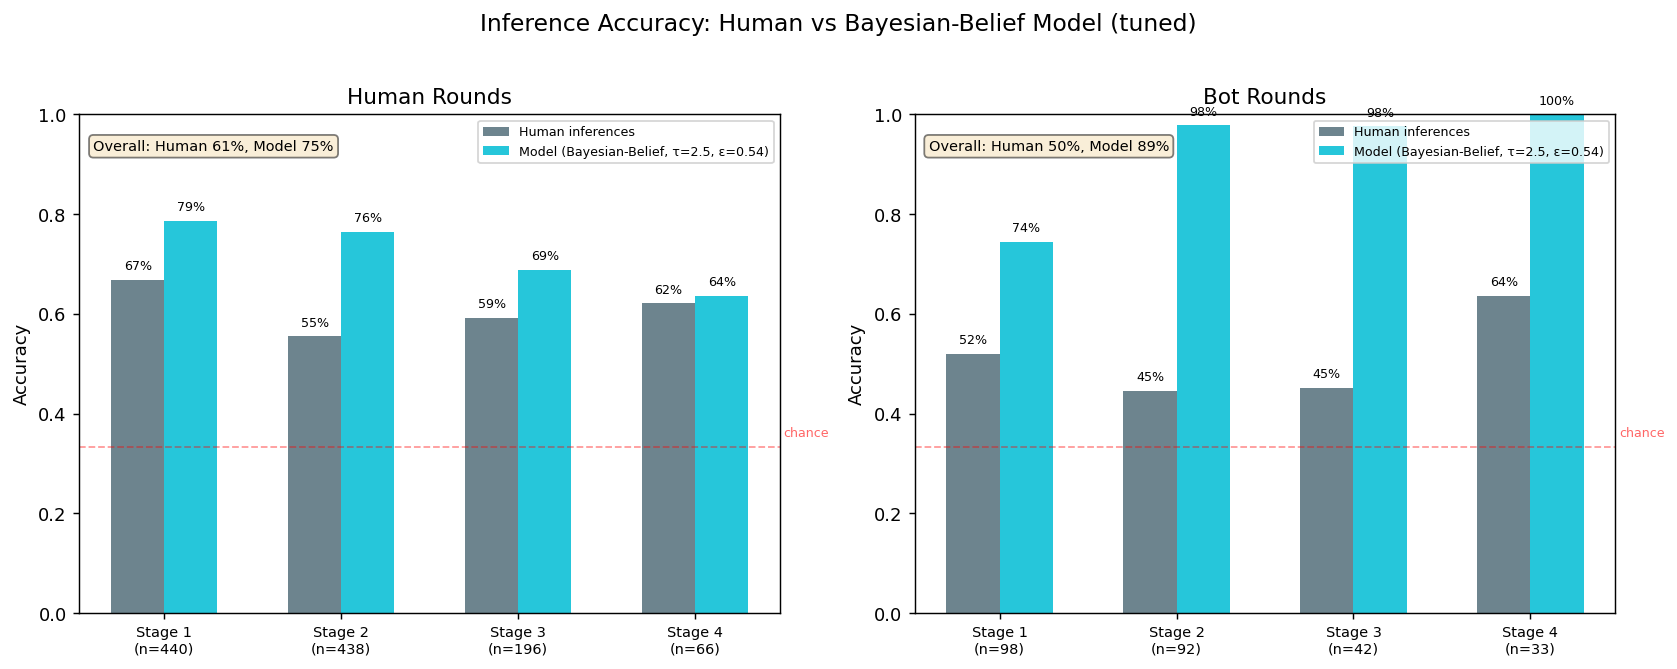


=== Summary ===

HUMAN rounds (1140 observations):
  Human accuracy: 60.9%
  Model accuracy: 75.3%
  Agreement (human == model): 57.8%

BOT rounds (265 observations):
  Human accuracy: 49.8%
  Model accuracy: 89.4%
  Agreement (human == model): 46.0%


In [4]:
# === Figure 1: Accuracy comparison by stage and round type ===

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_idx, (rt, title) in enumerate([('human', 'Human Rounds'), ('bot', 'Bot Rounds')]):
    ax = axes[ax_idx]
    sub = obs_df[obs_df.round_type == rt]
    stages = sorted(sub.stage.unique())
    human_accs, model_accs, ns = [], [], []
    for s in stages:
        ss = sub[sub.stage == s]
        human_accs.append(ss.human_correct.mean())
        model_accs.append(ss.model_correct.mean())
        ns.append(len(ss))
    x = np.arange(len(stages))
    w = 0.3
    ax.bar(x - w/2, human_accs, w, label='Human inferences', color='#546E7A', alpha=0.85)
    ax.bar(x + w/2, model_accs, w, label=f'Model (Bayesian-Belief, τ={TAU_PRIOR:.1f}, ε={EPSILON:.2f})', color='#00BCD4', alpha=0.85)
    ax.axhline(y=1/3, color='r', linestyle='--', alpha=0.4, linewidth=1)
    ax.text(len(stages) - 0.5, 1/3 + 0.02, 'chance', fontsize=7, color='r', alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Stage {s}\n(n={n})' for s, n in zip(stages, ns)], fontsize=8)
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=7)
    for i, (ha, ma) in enumerate(zip(human_accs, model_accs)):
        ax.text(i - w/2, ha + 0.02, f'{ha:.0%}', ha='center', fontsize=7)
        ax.text(i + w/2, ma + 0.02, f'{ma:.0%}', ha='center', fontsize=7)
    overall_h = sub.human_correct.mean()
    overall_m = sub.model_correct.mean()
    ax.text(0.02, 0.95, f'Overall: Human {overall_h:.0%}, Model {overall_m:.0%}',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Inference Accuracy: Human vs Bayesian-Belief Model (tuned)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig1_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print("\n=== Summary ===")
for rt in ['human', 'bot']:
    sub = obs_df[obs_df.round_type == rt]
    print(f"\n{rt.upper()} rounds ({len(sub)} observations):")
    print(f"  Human accuracy: {sub.human_correct.mean():.1%}")
    print(f"  Model accuracy: {sub.model_correct.mean():.1%}")
    print(f"  Agreement (human == model): {sub.human_agrees_model.mean():.1%}")

## 2. Agreement: When do humans and the model disagree?

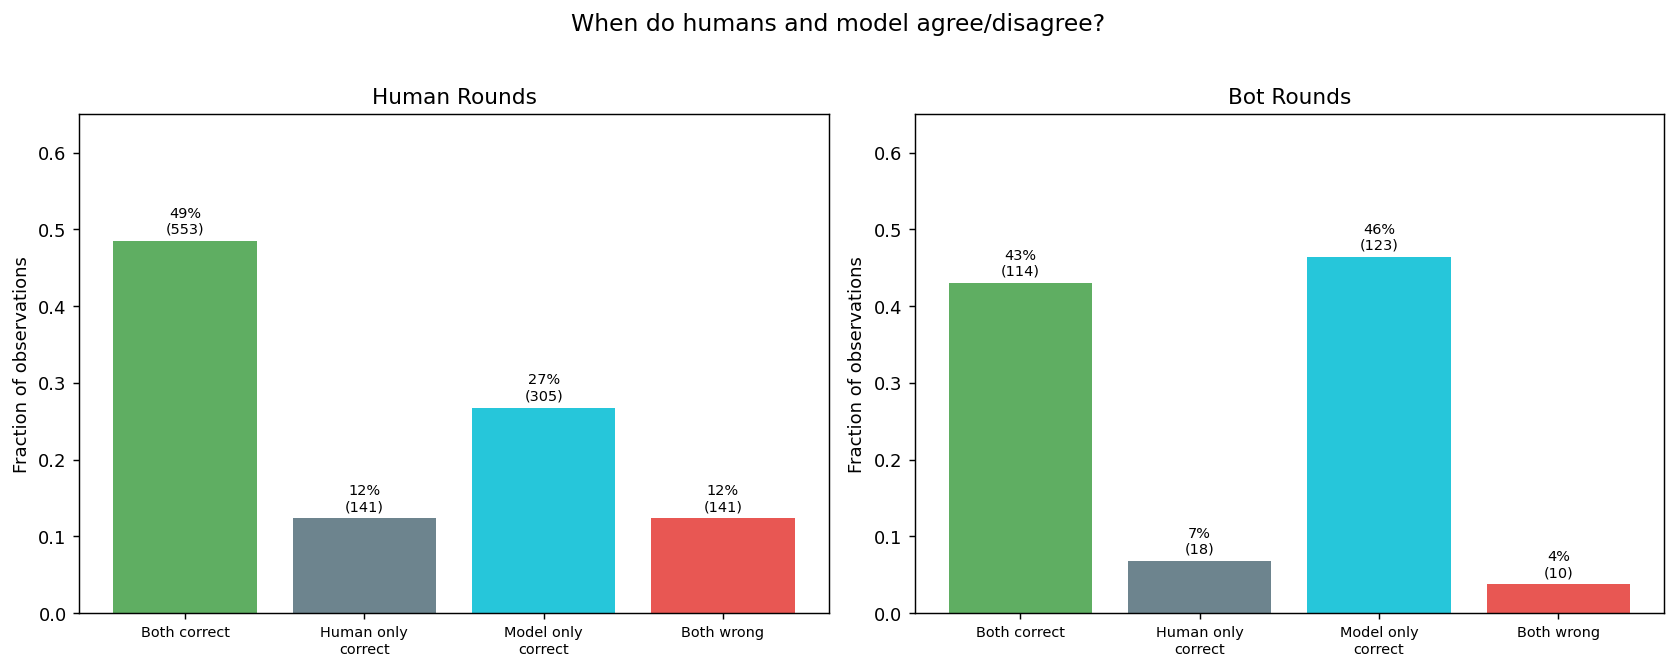


=== When both wrong: what do they infer? ===
  human: 141 cases, agree with each other 75% of the time
  bot: 10 cases, agree with each other 80% of the time


In [5]:
# === Figure 2: Agreement breakdown ===

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_idx, (rt, title) in enumerate([('human', 'Human Rounds'), ('bot', 'Bot Rounds')]):
    ax = axes[ax_idx]
    sub = obs_df[obs_df.round_type == rt]
    both_right = ((sub.human_correct) & (sub.model_correct)).sum()
    human_only = ((sub.human_correct) & (~sub.model_correct)).sum()
    model_only = ((~sub.human_correct) & (sub.model_correct)).sum()
    both_wrong = ((~sub.human_correct) & (~sub.model_correct)).sum()
    n = len(sub)
    cats = ['Both correct', 'Human only\ncorrect', 'Model only\ncorrect', 'Both wrong']
    vals = [both_right/n, human_only/n, model_only/n, both_wrong/n]
    colors = ['#43A047', '#546E7A', '#00BCD4', '#E53935']
    bars = ax.bar(range(4), vals, color=colors, alpha=0.85)
    ax.set_xticks(range(4))
    ax.set_xticklabels(cats, fontsize=8)
    ax.set_ylabel('Fraction of observations')
    ax.set_title(title)
    ax.set_ylim(0, 0.65)
    for i, (v, count) in enumerate(zip(vals, [both_right, human_only, model_only, both_wrong])):
        ax.text(i, v + 0.01, f'{v:.0%}\n({count})', ha='center', fontsize=8)

plt.suptitle('When do humans and model agree/disagree?', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig2_agreement_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== When both wrong: what do they infer? ===")
for rt in ['human', 'bot']:
    sub = obs_df[(obs_df.round_type == rt) & (~obs_df.human_correct) & (~obs_df.model_correct)]
    agree_when_wrong = (sub.human_inference == sub.model_top_role).mean()
    print(f"  {rt}: {len(sub)} cases, agree with each other {agree_when_wrong:.0%} of the time")

## 3. Model posterior confidence vs human accuracy

When the model is very confident about a target's role, are humans also more likely to get it right?

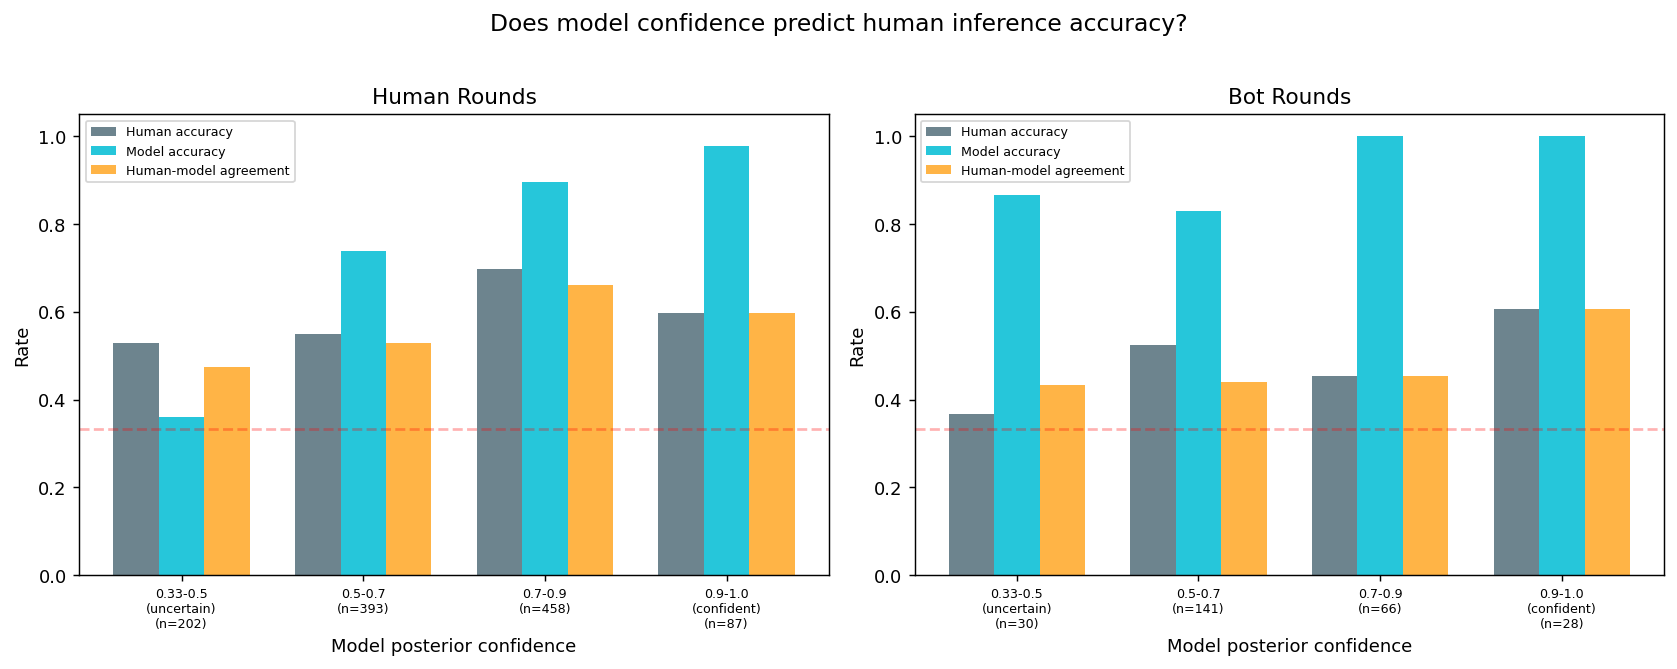

In [6]:
# === Figure 3: Model confidence vs human accuracy ===

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_idx, (rt, title) in enumerate([('human', 'Human Rounds'), ('bot', 'Bot Rounds')]):
    ax = axes[ax_idx]
    sub = obs_df[obs_df.round_type == rt].copy()
    sub['model_confidence'] = sub['model_marginal'].apply(lambda m: max(m))
    bins = [0.33, 0.5, 0.7, 0.9, 1.01]
    labels = ['0.33-0.5\n(uncertain)', '0.5-0.7', '0.7-0.9', '0.9-1.0\n(confident)']
    sub['conf_bin'] = pd.cut(sub['model_confidence'], bins=bins, labels=labels, include_lowest=True)
    grouped = sub.groupby('conf_bin', observed=True).agg(
        human_acc=('human_correct', 'mean'),
        model_acc=('model_correct', 'mean'),
        agreement=('human_agrees_model', 'mean'),
        n=('human_correct', 'count'),
    )
    x = np.arange(len(grouped))
    w = 0.25
    ax.bar(x - w, grouped['human_acc'], w, label='Human accuracy', color='#546E7A', alpha=0.85)
    ax.bar(x, grouped['model_acc'], w, label='Model accuracy', color='#00BCD4', alpha=0.85)
    ax.bar(x + w, grouped['agreement'], w, label='Human-model agreement', color='#FFA726', alpha=0.85)
    ax.axhline(y=1/3, color='r', linestyle='--', alpha=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{l}\n(n={n})' for l, n in zip(grouped.index, grouped['n'])], fontsize=7)
    ax.set_xlabel('Model posterior confidence')
    ax.set_ylabel('Rate')
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Does model confidence predict human inference accuracy?', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig3_confidence_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. How much history do humans use for inferences?

We test different "memory" strategies:
1. **Full history** — all turns from stage 0 onward
2. **Last stage only** — reset to prior, only use previous stage's turns
3. **Last 2 stages** — reset to prior, use turns from the 2 most recent stages
4. **Drift kernel** — at each stage boundary, mix posterior with prior: `post_new = (1-δ)·post + δ·prior`

Evaluated on Bayesian-Belief model (tau=2.533, epsilon=0.540).

In [7]:
# === History window analysis ===

def get_windowed_posteriors_team(team_prs, tau_prior, epsilon, window=None, drift_delta=0.0):
    """Compute posteriors with different memory strategies."""
    rnd = team_prs[0].round
    config = rnd.config
    parts = rnd.stat_profile_id.split('_')
    player_stats = np.array([[int(c) for c in part] for part in parts])
    boss_damage = config.get('bossDamage', 2)
    team_max_hp = config.get('maxTeamHealth', 15)
    eis = rnd.enemy_intent_sequence
    original_prior = utility_based_prior(player_stats, tau=tau_prior)
    player_roles = {}
    for pr in team_prs:
        player_roles[pr.player_id] = [s.role_idx for s in pr.round.stages]
    n_stages = max(len(roles) for roles in player_roles.values())

    # First pass: track HP per stage
    stage_posteriors = []
    team_hp_per_stage = [float(team_max_hp)]
    running_hp = float(team_max_hp)
    for s in range(n_stages):
        roles = [0, 0, 0]
        for pid, role_list in player_roles.items():
            if s < len(role_list): roles[pid] = role_list[s]
        stage_post = original_prior.copy()
        hp = running_hp
        for turn_offset in range(TURNS_PER_STAGE):
            turn_idx = s * TURNS_PER_STAGE + turn_offset
            if turn_idx >= len(eis) or hp <= 0: break
            intent = int(eis[turn_idx])
            actions = [preferred_action(roles[i], intent, hp, team_max_hp) for i in range(3)]
            stage_post = bayesian_update(stage_post, actions, intent, hp, team_max_hp, epsilon)
            hp, _ = game_step(intent, hp, float(config.get('maxEnemyHealth', 30)),
                              actions, player_stats, boss_damage, team_max_hp)
        stage_posteriors.append(stage_post)
        running_hp = hp
        team_hp_per_stage.append(hp)

    posteriors = [original_prior.copy()]
    if window is not None:
        for s in range(1, n_stages + 1):
            start = max(0, s - window)
            post = original_prior.copy()
            hp = team_hp_per_stage[start]
            for ws in range(start, s):
                roles = [0, 0, 0]
                for pid, role_list in player_roles.items():
                    if ws < len(role_list): roles[pid] = role_list[ws]
                for turn_offset in range(TURNS_PER_STAGE):
                    turn_idx = ws * TURNS_PER_STAGE + turn_offset
                    if turn_idx >= len(eis) or hp <= 0: break
                    intent = int(eis[turn_idx])
                    actions = [preferred_action(roles[i], intent, hp, team_max_hp) for i in range(3)]
                    post = bayesian_update(post, actions, intent, hp, team_max_hp, epsilon)
                    hp, _ = game_step(intent, hp, float(config.get('maxEnemyHealth', 30)),
                                      actions, player_stats, boss_damage, team_max_hp)
            posteriors.append(post)
    elif drift_delta > 0:
        current = original_prior.copy()
        hp = float(team_max_hp)
        for s in range(n_stages):
            roles = [0, 0, 0]
            for pid, role_list in player_roles.items():
                if s < len(role_list): roles[pid] = role_list[s]
            for turn_offset in range(TURNS_PER_STAGE):
                turn_idx = s * TURNS_PER_STAGE + turn_offset
                if turn_idx >= len(eis) or hp <= 0: break
                intent = int(eis[turn_idx])
                actions = [preferred_action(roles[i], intent, hp, team_max_hp) for i in range(3)]
                current = bayesian_update(current, actions, intent, hp, team_max_hp, epsilon)
                hp, _ = game_step(intent, hp, float(config.get('maxEnemyHealth', 30)),
                                  actions, player_stats, boss_damage, team_max_hp)
            current = (1 - drift_delta) * current + drift_delta * original_prior
            total = current.sum()
            if total > 0: current /= total
            posteriors.append(current.copy())
    else:
        current = original_prior.copy()
        hp = float(team_max_hp)
        for s in range(n_stages):
            roles = [0, 0, 0]
            for pid, role_list in player_roles.items():
                if s < len(role_list): roles[pid] = role_list[s]
            for turn_offset in range(TURNS_PER_STAGE):
                turn_idx = s * TURNS_PER_STAGE + turn_offset
                if turn_idx >= len(eis) or hp <= 0: break
                intent = int(eis[turn_idx])
                actions = [preferred_action(roles[i], intent, hp, team_max_hp) for i in range(3)]
                current = bayesian_update(current, actions, intent, hp, team_max_hp, epsilon)
                hp, _ = game_step(intent, hp, float(config.get('maxEnemyHealth', 30)),
                                  actions, player_stats, boss_damage, team_max_hp)
            posteriors.append(current.copy())
    return posteriors


def evaluate_strategy(strategy_name, posteriors_by_team, human_teams, bot_records, tau_prior, epsilon):
    """Evaluate a memory strategy: accuracy + log-likelihood of human inferences."""
    correct, total = 0, 0
    log_liks = []
    for (gid, rnum), team_prs in human_teams.items():
        if len(team_prs) != 3: continue
        team_prs_sorted = sorted(team_prs, key=lambda p: p.player_id)
        posteriors = posteriors_by_team[(gid, rnum)]
        player_roles = {}
        for pr in team_prs_sorted:
            player_roles[pr.player_id] = [s.role_idx for s in pr.round.stages]
        for pr in team_prs_sorted:
            for si, stage in enumerate(pr.round.stages):
                if si == 0 or not stage.inferred_roles: continue
                if si >= len(posteriors): continue
                post = posteriors[si]
                for target_pos, human_inferred_role in stage.inferred_roles.items():
                    if target_pos in player_roles and si - 1 < len(player_roles[target_pos]):
                        actual_role = player_roles[target_pos][si - 1]
                    else: continue
                    marg = np.sum(post, axis=tuple(j for j in range(3) if j != target_pos))
                    t = marg.sum()
                    if t > 0: marg /= t
                    total += 1
                    if int(np.argmax(marg)) == actual_role: correct += 1
                    log_liks.append(np.log(max(marg[human_inferred_role], 1e-20)))
    return {
        'strategy': strategy_name,
        'accuracy': correct / total if total > 0 else 0,
        'mean_ll': np.mean(log_liks) if log_liks else float('nan'),
        'n': total,
    }


# === Run all strategies for Bayesian-Belief ===
strategies = [
    ('Full history', dict(window=None, drift_delta=0.0)),
    ('Last 1 stage', dict(window=1, drift_delta=0.0)),
    ('Last 2 stages', dict(window=2, drift_delta=0.0)),
    ('Drift δ=0.1', dict(window=None, drift_delta=0.1)),
    ('Drift δ=0.3', dict(window=None, drift_delta=0.3)),
    ('Drift δ=0.5', dict(window=None, drift_delta=0.5)),
    ('Drift δ=0.7', dict(window=None, drift_delta=0.7)),
]

bb_results = []
for name, kwargs in strategies:
    print(f"Running {name}...")
    posteriors_by_team = {}
    for (gid, rnum), team_prs in human_teams.items():
        if len(team_prs) != 3: continue
        team_prs_sorted = sorted(team_prs, key=lambda p: p.player_id)
        posteriors_by_team[(gid, rnum)] = get_windowed_posteriors_team(
            team_prs_sorted, TAU_PRIOR, EPSILON, **kwargs)
    res = evaluate_strategy(name, posteriors_by_team, human_teams, bot_records, TAU_PRIOR, EPSILON)
    bb_results.append(res)
    print(f"  accuracy={res['accuracy']:.1%}, mean_ll={res['mean_ll']:.3f} (n={res['n']})")

print("\nDone.")

Running Full history...
  accuracy=75.3%, mean_ll=-1.004 (n=1140)
Running Last 1 stage...
  accuracy=71.9%, mean_ll=-0.944 (n=1140)
Running Last 2 stages...
  accuracy=76.1%, mean_ll=-0.970 (n=1140)
Running Drift δ=0.1...
  accuracy=78.2%, mean_ll=-0.971 (n=1140)
Running Drift δ=0.3...
  accuracy=74.9%, mean_ll=-0.955 (n=1140)
Running Drift δ=0.5...
  accuracy=73.1%, mean_ll=-0.965 (n=1140)
Running Drift δ=0.7...
  accuracy=73.6%, mean_ll=-0.988 (n=1140)

Done.


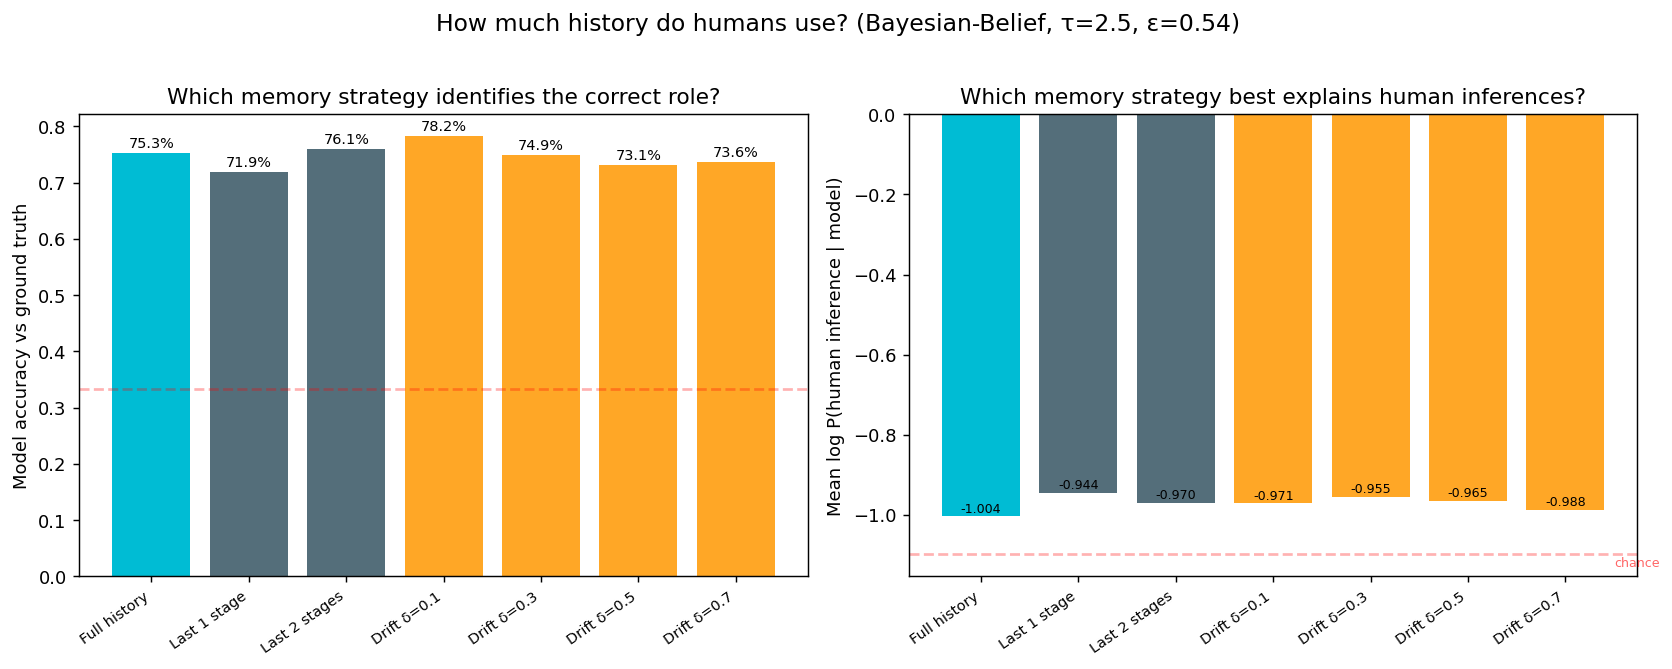


Best model accuracy: Drift δ=0.1 (78.2%)
Best fit to human inferences: Last 1 stage (LL=-0.944)


In [8]:
# === Figure 4: History window comparison (Bayesian-Belief only) ===

res_df = pd.DataFrame(bb_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Model accuracy
ax = axes[0]
bars = ax.bar(range(len(res_df)), res_df['accuracy'],
              color=['#00BCD4' if 'Full' in n else '#FFA726' if 'Drift' in n else '#546E7A'
                     for n in res_df['strategy']])
ax.set_xticks(range(len(res_df)))
ax.set_xticklabels(res_df['strategy'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Model accuracy vs ground truth')
ax.set_title('Which memory strategy identifies the correct role?')
ax.axhline(y=1/3, color='r', linestyle='--', alpha=0.3)
for i, v in enumerate(res_df['accuracy']):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=8)

# Right: Log-likelihood
ax = axes[1]
bars = ax.bar(range(len(res_df)), res_df['mean_ll'],
              color=['#00BCD4' if 'Full' in n else '#FFA726' if 'Drift' in n else '#546E7A'
                     for n in res_df['strategy']])
ax.set_xticks(range(len(res_df)))
ax.set_xticklabels(res_df['strategy'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Mean log P(human inference | model)')
ax.set_title('Which memory strategy best explains human inferences?')
ax.axhline(y=np.log(1/3), color='r', linestyle='--', alpha=0.3)
ax.text(len(res_df) - 0.5, np.log(1/3) - 0.03, 'chance', fontsize=7, color='r', alpha=0.6)
for i, v in enumerate(res_df['mean_ll']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=7)

plt.suptitle(f'How much history do humans use? (Bayesian-Belief, τ={TAU_PRIOR:.1f}, ε={EPSILON:.2f})', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig4_history_window.png', dpi=150, bbox_inches='tight')
plt.show()

best_acc = res_df.loc[res_df['accuracy'].idxmax()]
best_ll = res_df.loc[res_df['mean_ll'].idxmax()]
print(f"\nBest model accuracy: {best_acc['strategy']} ({best_acc['accuracy']:.1%})")
print(f"Best fit to human inferences: {best_ll['strategy']} (LL={best_ll['mean_ll']:.3f})")

## 5. History window across all 8 Bayesian models

Each model has different tau_prior and epsilon values. We test all 8 models with 6 memory strategies.

In [9]:
# === Run all 8 models x 6 strategies ===
# For inference comparison, only the tau_prior and epsilon matter (posterior computation).
# The model's role-choice mechanism doesn't affect inference posteriors.

model_configs = {
    'Bayesian-Belief': {'tau_prior': all_params['bb']['aggregate_tuned']['tau_prior'],
                        'epsilon': all_params['bb']['aggregate_tuned']['epsilon']},
    'Bayesian Walk PS': {'tau_prior': all_params['bwps']['aggregate_tuned']['tau_prior'],
                         'epsilon': all_params['bwps']['aggregate_tuned']['epsilon']},
    'Bayesian Thresh PS': {'tau_prior': all_params['btps']['aggregate_tuned']['tau_prior'],
                           'epsilon': all_params['btps']['aggregate_tuned']['epsilon']},
    'Mixture PS': {'tau_prior': all_params['mps']['aggregate_tuned']['tau_prior'],
                   'epsilon': all_params['mps']['aggregate_tuned']['epsilon']},
    'Bayesian Walk': {'tau_prior': all_params['bw']['aggregate_tuned']['tau_prior'],
                      'epsilon': all_params['bw']['aggregate_tuned']['epsilon']},
    'Bayesian Threshold': {'tau_prior': all_params['bt']['aggregate_tuned']['bayesian_thresh']['tau_prior'],
                           'epsilon': all_params['bt']['aggregate_tuned']['bayesian_thresh']['epsilon']},
    'Bayesian-Value': {'tau_prior': all_params['bv']['aggregate_tuned']['tau_prior'],
                       'epsilon': all_params['bv']['aggregate_tuned']['epsilon']},
    'Random Walk': {'tau_prior': all_params['bwps']['aggregate_tuned']['tau_prior'],
                    'epsilon': all_params['bwps']['aggregate_tuned']['epsilon']},  # RW uses same inference engine
}

hist_strategies = [
    ('Full', dict(window=None, drift_delta=0.0)),
    ('Last1', dict(window=1, drift_delta=0.0)),
    ('Last2', dict(window=2, drift_delta=0.0)),
    ('Drift0.1', dict(window=None, drift_delta=0.1)),
    ('Drift0.3', dict(window=None, drift_delta=0.3)),
    ('Drift0.5', dict(window=None, drift_delta=0.5)),
]

all_hist_results = []
for model_name, mcfg in model_configs.items():
    tau_p, eps = mcfg['tau_prior'], mcfg['epsilon']
    print(f"Running {model_name} (τ={tau_p:.2f}, ε={eps:.3f})...")
    for strat_name, kwargs in hist_strategies:
        posteriors_by_team = {}
        for (gid, rnum), team_prs in human_teams.items():
            if len(team_prs) != 3: continue
            team_prs_sorted = sorted(team_prs, key=lambda p: p.player_id)
            posteriors_by_team[(gid, rnum)] = get_windowed_posteriors_team(
                team_prs_sorted, tau_p, eps, **kwargs)
        res = evaluate_strategy(strat_name, posteriors_by_team, human_teams, bot_records, tau_p, eps)
        all_hist_results.append({
            'model': model_name, 'strategy': strat_name,
            'acc': res['accuracy'], 'll': res['mean_ll'], 'n': res['n'],
        })
    print(f"  Done.")

hist_df = pd.DataFrame(all_hist_results)

# Save to JSON
hist_df.to_json(OUT_DIR / 'history_all_models.json', orient='records', indent=2)
print(f"\nSaved {len(hist_df)} results to history_all_models.json")

Running Bayesian-Belief (τ=2.53, ε=0.540)...
  Done.
Running Bayesian Walk PS (τ=1.74, ε=0.489)...


  Done.
Running Bayesian Thresh PS (τ=1.25, ε=0.000)...
  Done.
Running Mixture PS (τ=1.46, ε=0.005)...


  Done.
Running Bayesian Walk (τ=7.40, ε=0.883)...
  Done.
Running Bayesian Threshold (τ=6.00, ε=0.933)...


  Done.
Running Bayesian-Value (τ=6.07, ε=0.813)...
  Done.
Running Random Walk (τ=1.74, ε=0.489)...


  Done.

Saved 48 results to history_all_models.json


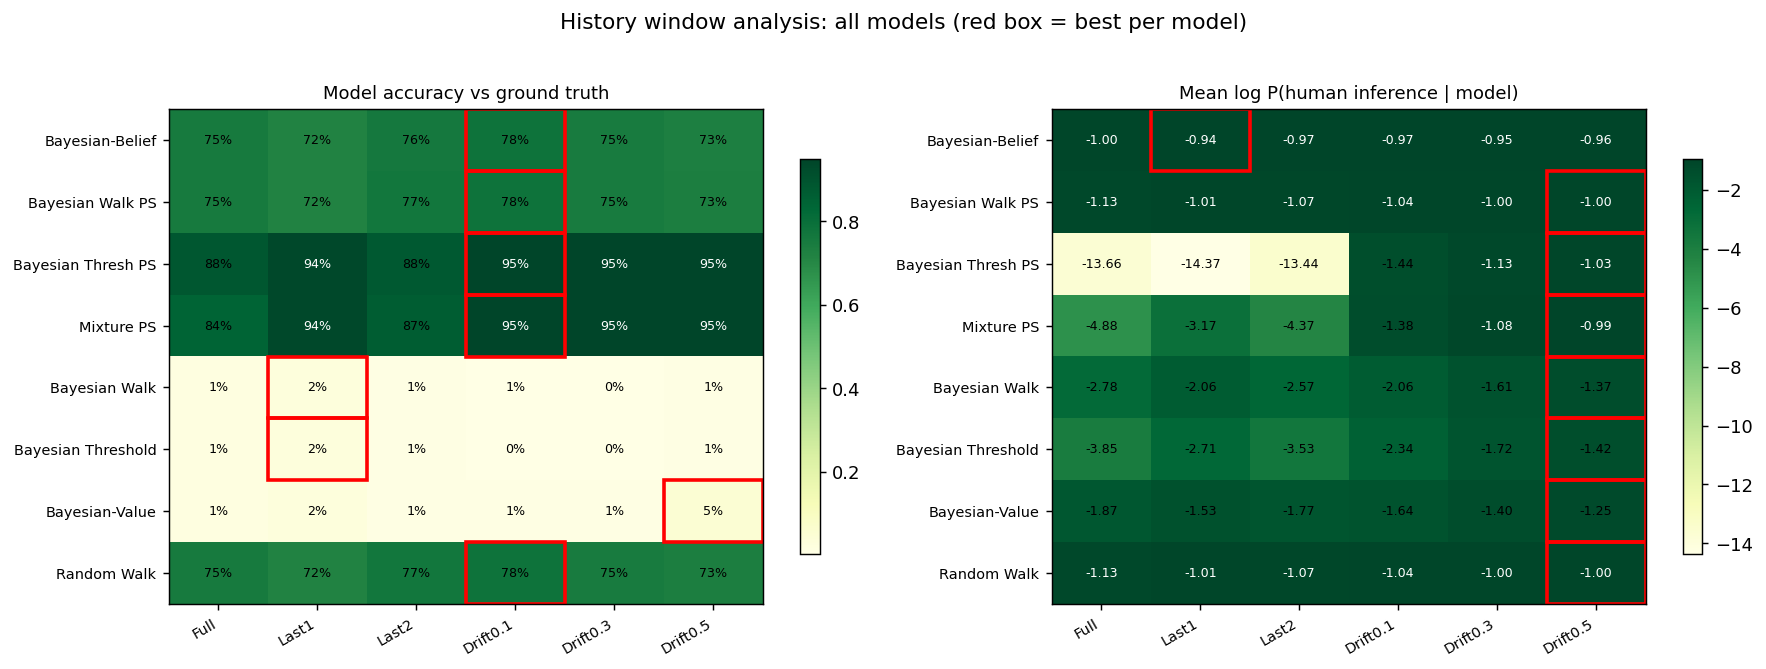


=== Best strategy per model ===
Model                      Best acc   Strategy    Best LL   Strategy
----------------------------------------------------------------------
  Bayesian-Belief            78.2%   Drift0.1     -0.944      Last1
  Bayesian Walk PS           78.2%   Drift0.1     -0.998   Drift0.5
  Bayesian Thresh PS         95.0%   Drift0.1     -1.033   Drift0.5
  Mixture PS                 95.0%   Drift0.1     -0.995   Drift0.5
  Bayesian Walk               2.5%      Last1     -1.367   Drift0.5
  Bayesian Threshold          2.5%      Last1     -1.420   Drift0.5
  Bayesian-Value              5.0%   Drift0.5     -1.250   Drift0.5
  Random Walk                78.2%   Drift0.1     -0.998   Drift0.5


In [10]:
# === Figure 5: Heatmap of accuracy across models x strategies ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = list(model_configs.keys())
strats = [s[0] for s in hist_strategies]

for ax_idx, (metric, title, fmt, cmap) in enumerate([
    ("acc", "Model accuracy vs ground truth", ".0%", "YlGn"),
    ("ll", "Mean log P(human inference | model)", ".2f", "YlGn"),
]):
    ax = axes[ax_idx]
    data = np.zeros((len(models), len(strats)))
    for i, m in enumerate(models):
        for j, s in enumerate(strats):
            row = hist_df[(hist_df.model == m) & (hist_df.strategy == s)]
            data[i, j] = row[metric].values[0] if len(row) > 0 else np.nan

    im = ax.imshow(data, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(strats)))
    ax.set_xticklabels(strats, fontsize=8, rotation=30, ha="right")
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models, fontsize=8)
    ax.set_title(title, fontsize=10)

    for i in range(len(models)):
        for j in range(len(strats)):
            v = data[i, j]
            if not np.isnan(v):
                txt = f"{v:{fmt}}"
                color = "white" if (metric == "acc" and v > 0.9) or (metric == "ll" and v > -1.2) else "black"
                ax.text(j, i, txt, ha="center", va="center", fontsize=7, color=color)
        # Mark best per model
        best_j = int(np.nanargmax(data[i, :]))
        ax.add_patch(plt.Rectangle((best_j-0.5, i-0.5), 1, 1, fill=False, edgecolor="red", linewidth=2))
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("History window analysis: all models (red box = best per model)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig5_all_models_history.png", dpi=150, bbox_inches="tight")
plt.show()

# Print best strategy per model
print("\n=== Best strategy per model ===")
print(f"{'Model':<22} {'Best acc':>12} {'Strategy':>10} {'Best LL':>10} {'Strategy':>10}")
print("-" * 70)
for m in models:
    sub = hist_df[hist_df.model == m]
    best_acc = sub.loc[sub.acc.idxmax()]
    best_ll = sub.loc[sub.ll.idxmax()]
    print(f"  {m:<20} {best_acc.acc:>11.1%} {best_acc.strategy:>10} {best_ll.ll:>10.3f} {best_ll.strategy:>10}")

## Summary

**Sections 1-3 (Bayesian-Belief with tuned params: τ=2.533, ε=0.540):**

- **Human rounds:** Model (75%) substantially outperforms humans (61%). Both well above chance (33%).
- **Bot rounds:** Gap is even larger: model 89% vs human 50%.
- **Agreement:** 58% in human rounds, 46% in bot rounds. Most common disagreement is "model correct, human wrong."
- **Confidence:** When the model is confident (>0.9), human accuracy rises to ~65% and agreement to ~68% in human rounds.

**Section 4-5 (History window):**

- **Drift δ=0.1** is best for accuracy (78.2%) across PS models and Bayesian-Belief.
- **Last 1 stage** or **Drift δ=0.3-0.5** best explains human inferences (highest LL).
- Full history is never the best strategy — confirming humans do not do perfect sequential Bayesian updating.
- **Value-based models** (Bayesian Walk, Threshold, Value) have very high epsilon (0.8-0.9), making their posteriors nearly uniform. These models are designed for role-choice prediction, not inference — their observation model is too noisy for posterior concentration. PS models with lower epsilon are more appropriate for inference comparison.

**Key finding vs 04-02:** Using Bhavyesh's tuned params (τ=2.533, ε=0.540) instead of default (2.0, 0.5), the Bayesian-Belief model shows similar overall accuracy (75% vs 75%) but slightly different per-stage patterns. The tuned parameters also yield better log-likelihood fits to human inferences (LL=-1.004 vs -1.082).